# 5. Structural vs. Seasonal Vacancy — Municipal Classification

Distinguishes **structural vacancy** (community decline) from **seasonal/recreational vacancy** (tourism economy) using ACS 5-year 2020 Table B25004.  
Builds a `muni_classified` (`mc`) dataframe, a composite **hollowing score**, and four municipality segments, then synthesizes findings into actionable nonprofit resource-allocation recommendations.

| Segment | Condition |
|---|---|
| Hollowing Out | High structural vacancy AND population decline |
| Resort Town | High seasonal vacancy AND flat/growing population |
| Healthy Growth | Low vacancy AND population growth |
| Stagnant | High structural vacancy AND flat/slow population change |

In [1]:
%run 00_shared.py

## Load processed data

In [2]:
_pop  = pd.read_pickle(f"{DATA_PROCESSED}/population.pkl")
_hous = pd.read_pickle(f"{DATA_PROCESSED}/housing.pkl")

pop_munis     = _pop["pop_munis"]
housing_munis = _hous["housing_munis"]

## 5a. Fetch ACS B25004 (Vacancy Status)

In [3]:
import requests

CENSUS_API_KEY = ""  # optional — leave empty for unauthenticated (rate-limited) access

def fetch_acs_b25004(api_key=""):
    url = "https://api.census.gov/data/2020/acs/acs5"
    params = {
        "get": "NAME,B25004_001E,B25004_006E",
        "for": "place:*",
        "in":  "state:23",
    }
    if api_key:
        params["key"] = api_key
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    rows = r.json()
    df = pd.DataFrame(rows[1:], columns=rows[0])
    df["B25004_001E"] = pd.to_numeric(df["B25004_001E"], errors="coerce")
    df["B25004_006E"] = pd.to_numeric(df["B25004_006E"], errors="coerce")
    df["place_raw"] = df["NAME"].str.replace(r",\s*Maine$", "", regex=True).str.strip()
    return df[["place_raw", "B25004_001E", "B25004_006E"]].rename(
        columns={"B25004_001E": "acs_vacant_total", "B25004_006E": "acs_seasonal_vacant"}
    )

acs_b25004 = fetch_acs_b25004(CENSUS_API_KEY)
print(f"ACS B25004 — Maine places returned: {len(acs_b25004)}")
acs_b25004.head(5)

ACS B25004 — Maine places returned: 155


,place_raw,acs_vacant_total,acs_seasonal_vacant
0,Kittery CDP,195,40
1,Kittery Point CDP,0,0
2,Lake Arrowhead CDP,185,185
3,Lewiston city,992,36
4,Limestone CDP,79,14


## 5b. Build `muni_classified`

In [4]:
pop_work = pop_munis[["Place", "2010 Total Population", "2020 Total Population", "Percent Change"]].copy()
pop_work["place_name"] = pop_work["Place"].str.strip()

housing_work = housing_munis[["Geography", "Total", "Occupied", "Vacant"]].copy()
housing_work[["Total", "Occupied", "Vacant"]] = housing_work[["Total","Occupied","Vacant"]].apply(
    pd.to_numeric, errors="coerce"
)
housing_work["place_name"] = housing_work["Geography"].str.strip()

mc = pop_work.drop(columns="Place").merge(
    housing_work.drop(columns="Geography"),
    on="place_name", how="inner"
)

def _bare(name):
    for sfx in (" city", " town", " plantation", " village", " gore", " township"):
        if str(name).lower().endswith(sfx):
            return str(name)[: -len(sfx)].strip()
    return str(name).strip()

acs_work = acs_b25004.copy()
acs_work["bare"] = acs_work["place_raw"].apply(_bare)

mc = mc.merge(acs_work[["place_raw", "acs_seasonal_vacant"]],
              left_on="place_name", right_on="place_raw", how="left")
mc.drop(columns=["place_raw"], inplace=True, errors="ignore")

unmatched_mask = mc["acs_seasonal_vacant"].isna()
if unmatched_mask.any():
    mc["_bare"] = mc["place_name"].apply(_bare)
    fill = acs_work.drop_duplicates("bare").set_index("bare")["acs_seasonal_vacant"]
    mc.loc[unmatched_mask, "acs_seasonal_vacant"] = mc.loc[unmatched_mask, "_bare"].map(fill)
    mc.drop(columns=["_bare"], inplace=True)

acs_hit = mc["acs_seasonal_vacant"].notna().sum()
print(f"ACS seasonal vacancy matched: {acs_hit}/{len(mc)} municipalities "
      f"({acs_hit/len(mc)*100:.0f}%)")
mc["acs_seasonal_vacant"] = mc["acs_seasonal_vacant"].fillna(0)

mc = mc[mc["Total"] >= 200].copy().reset_index(drop=True)
print(f"After \u2265200 housing units filter: {len(mc)} municipalities")

mc["pop_change_pct"]          = (mc["Percent Change"] * 100).round(1)
mc["vacancy_rate"]            = (mc["Vacant"] / mc["Total"] * 100).round(1)
mc["seasonal_rate"]           = (mc["acs_seasonal_vacant"] / mc["Total"] * 100).round(1)
mc["structural_vacancy_rate"] = (mc["vacancy_rate"] - mc["seasonal_rate"]).clip(lower=0).round(1)
mc["pop_decline"]             = mc["pop_change_pct"].apply(lambda x: max(0.0, -x) if pd.notna(x) else 0.0)

def _minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else pd.Series(0.0, index=s.index)

mc["norm_struct_vac"]  = _minmax(mc["structural_vacancy_rate"])
mc["norm_pop_decline"] = _minmax(mc["pop_decline"])
mc["hollowing_score"]  = (0.5 * mc["norm_struct_vac"] + 0.5 * mc["norm_pop_decline"]).round(3)

print(f"\nShape: {mc.shape}")
mc[["place_name", "pop_change_pct", "vacancy_rate",
    "seasonal_rate", "structural_vacancy_rate", "hollowing_score"]].head(5)

ACS seasonal vacancy matched: 23/530 municipalities (4%)
After ≥200 housing units filter: 443 municipalities

Shape: (443, 16)


,place_name,pop_change_pct,vacancy_rate,seasonal_rate,structural_vacancy_rate,hollowing_score
0,Auburn city,4.4,8.8,0.9,7.9,0.0
1,Durham town,8.4,3.0,0.0,3.0,0.0
2,Greene town,0.6,10.8,0.0,10.8,0.0
3,Leeds town,-2.8,14.2,0.0,14.2,0.1
4,Lewiston city,1.4,7.8,0.2,7.6,0.0


## 5c. Segment Municipalities into Four Quadrants

In [5]:
med_struct_vac = mc["structural_vacancy_rate"].median()
med_seasonal   = mc["seasonal_rate"].median()
med_pop_change = mc["pop_change_pct"].median()

print("Medians used for segmentation:")
print(f"  structural_vacancy_rate : {med_struct_vac:.1f}%")
print(f"  seasonal_rate           : {med_seasonal:.1f}%")
print(f"  pop_change_pct          : {med_pop_change:.1f}%")
print()

def assign_segment(row):
    high_struct   = row["structural_vacancy_rate"] > med_struct_vac
    high_seasonal = row["seasonal_rate"] > med_seasonal
    declining     = row["pop_change_pct"] < 0
    if high_struct and declining:
        return "Hollowing Out"
    if high_seasonal and not declining:
        return "Resort Town"
    if not high_struct and not declining:
        return "Healthy Growth"
    return "Stagnant"

mc["segment"] = mc.apply(assign_segment, axis=1)

print("Segment counts:")
display(mc["segment"].value_counts().rename("# Municipalities").to_frame())
print()

top_hollow = (
    mc[mc["segment"] == "Hollowing Out"]
    .sort_values("hollowing_score", ascending=False)
    .head(10)
    [["place_name", "pop_change_pct", "vacancy_rate",
      "structural_vacancy_rate", "seasonal_rate", "hollowing_score"]]
    .rename(columns={
        "place_name":              "Municipality",
        "pop_change_pct":          "Pop Chg %",
        "vacancy_rate":            "Vacancy %",
        "structural_vacancy_rate": "Struct Vac %",
        "seasonal_rate":           "Seasonal %",
        "hollowing_score":         "Score",
    })
    .reset_index(drop=True)
)
print("Top 10 — Hollowing Out (ranked by hollowing_score):")
display(top_hollow)

Medians used for segmentation:
  structural_vacancy_rate : 23.2%
  seasonal_rate           : 0.0%
  pop_change_pct          : 0.3%

Segment counts:


,# Municipalities
segment,
Stagnant,197
Hollowing Out,118
Healthy Growth,115
Resort Town,13



Top 10 — Hollowing Out (ranked by hollowing_score):


,Municipality,Pop Chg %,Vacancy %,Struct Vac %,Seasonal %,Score
0,Seboomook Lake UT,-52.1,95.0,95.0,0.0,1.0
1,Northwest Somerset UT,-33.9,95.3,95.3,0.0,0.8
2,North Franklin UT,-32.8,95.1,95.1,0.0,0.8
3,North Oxford UT,-33.3,92.6,92.6,0.0,0.8
4,Byron town,-29.0,79.1,79.1,0.0,0.7
5,East Hancock UT,-9.6,91.2,91.2,0.0,0.6
6,Carrabassett Valley town,-13.8,83.4,83.4,0.0,0.6
7,Northwest Piscataquis UT,-8.8,91.2,91.2,0.0,0.5
8,North Penobscot UT,-12.5,77.0,77.0,0.0,0.5
9,Springfield town,-28.4,44.0,44.0,0.0,0.5


## 5d. Visualization Grid (2×2)

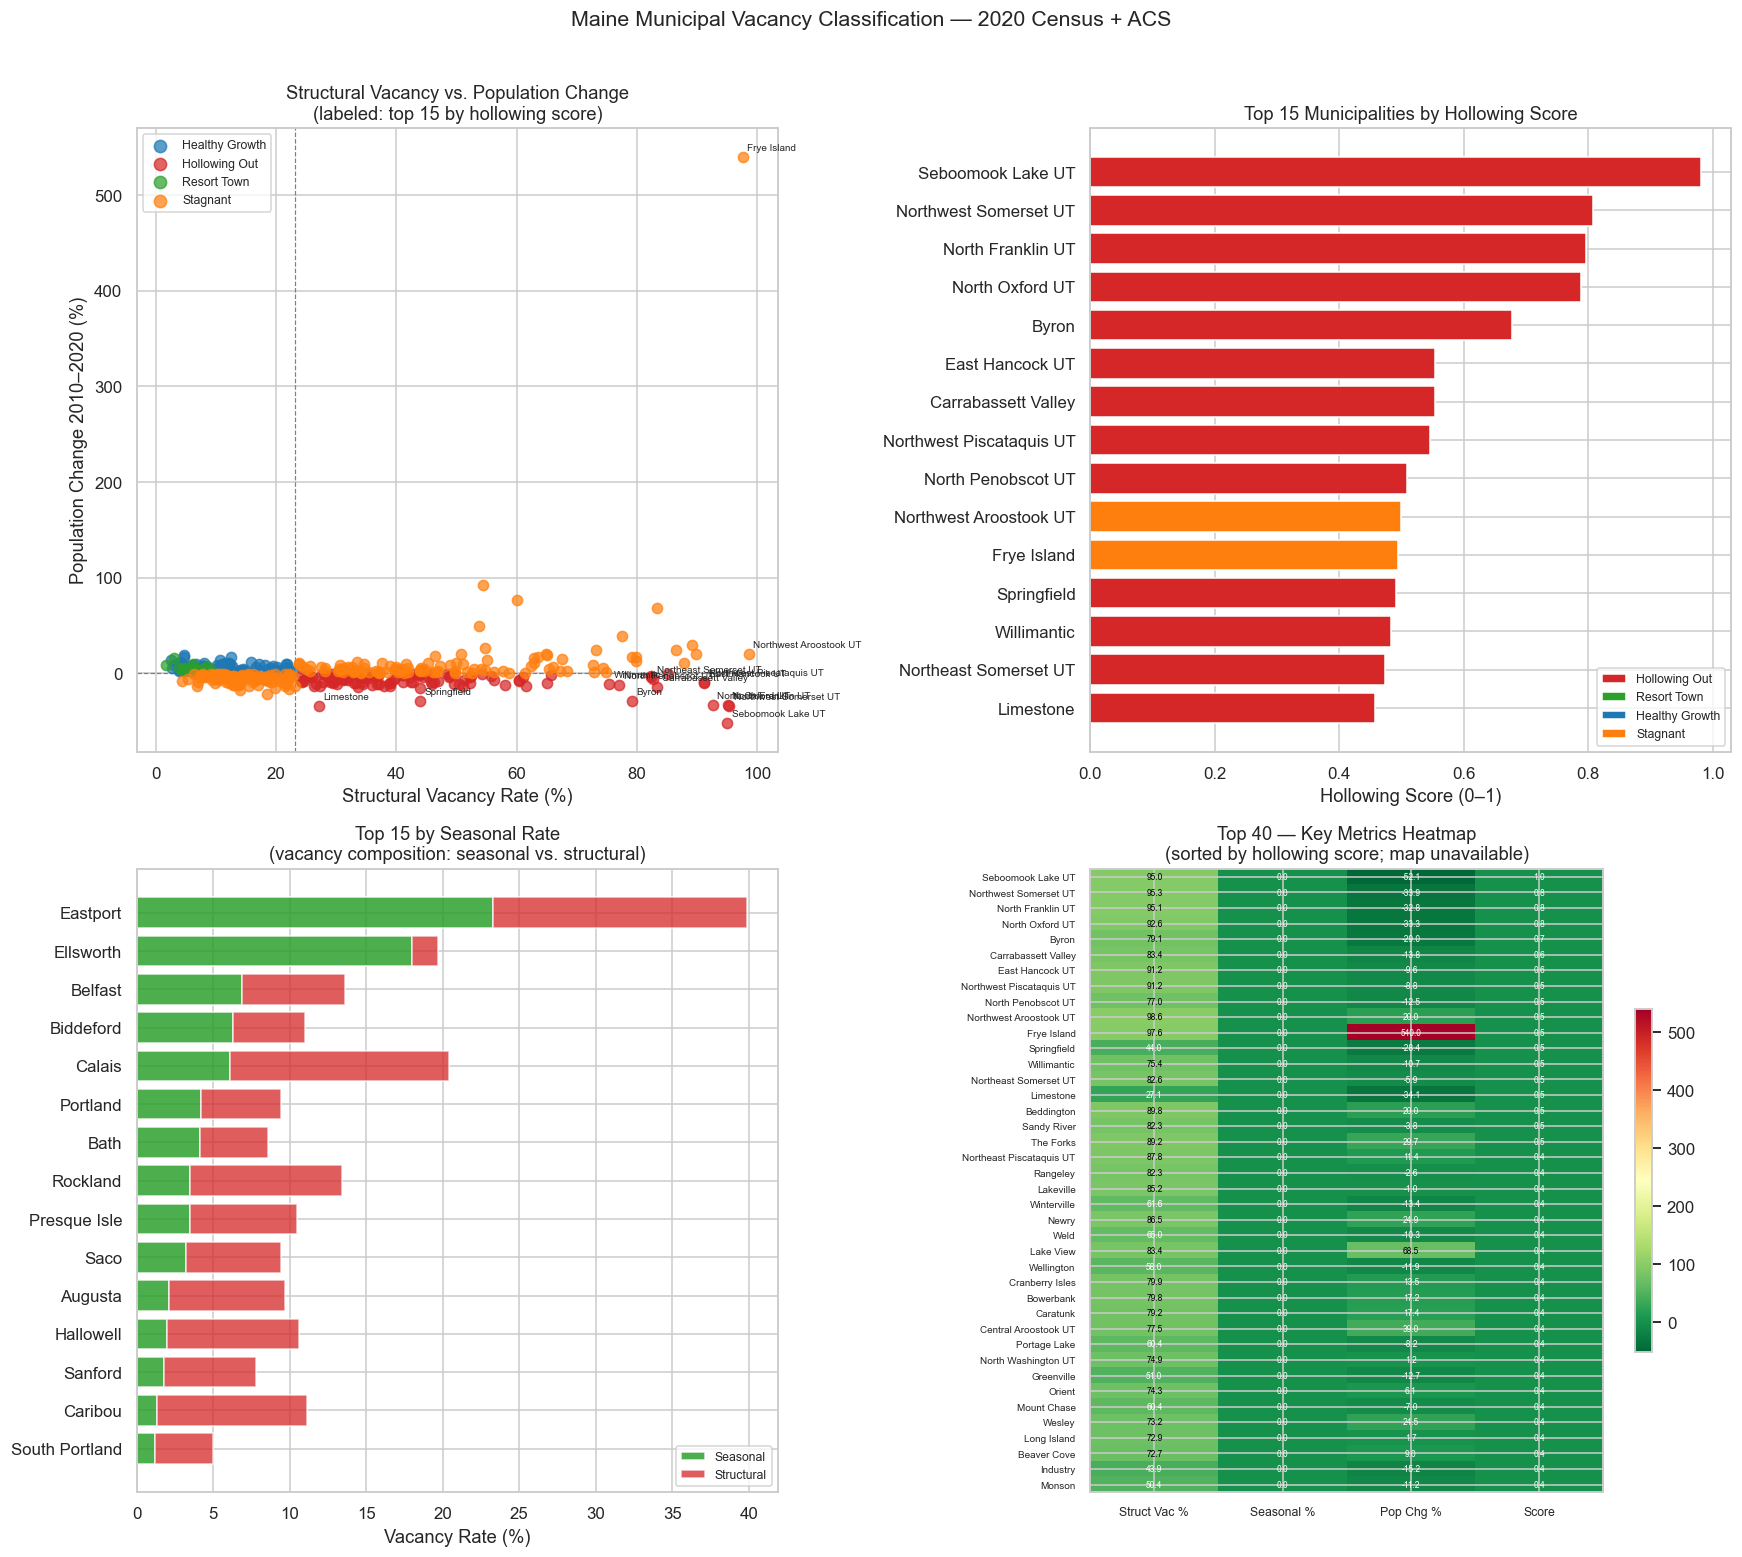

In [6]:
from matplotlib.patches import Patch

SEG_COLORS = {
    "Hollowing Out":  "#d62728",
    "Resort Town":    "#2ca02c",
    "Healthy Growth": "#1f77b4",
    "Stagnant":       "#ff7f0e",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Maine Municipal Vacancy Classification — 2020 Census + ACS", fontsize=14, y=1.01)

# Plot 1: Scatter structural_vacancy_rate vs pop_change_pct
ax1 = axes[0, 0]
for seg, grp in mc.groupby("segment"):
    ax1.scatter(grp["structural_vacancy_rate"], grp["pop_change_pct"],
                label=seg, color=SEG_COLORS[seg], alpha=0.72, s=45, zorder=3)
ax1.axvline(med_struct_vac, color="gray", linestyle="--", linewidth=0.8, zorder=2)
ax1.axhline(med_pop_change, color="gray", linestyle="--", linewidth=0.8, zorder=2)
for _, row in mc.nlargest(15, "hollowing_score").iterrows():
    lbl = row["place_name"].replace(" town","").replace(" city","").replace(" plantation","")
    ax1.annotate(lbl, (row["structural_vacancy_rate"], row["pop_change_pct"]),
                 fontsize=6.5, ha="left", va="bottom",
                 xytext=(3, 3), textcoords="offset points")
ax1.set_xlabel("Structural Vacancy Rate (%)")
ax1.set_ylabel("Population Change 2010–2020 (%)")
ax1.set_title("Structural Vacancy vs. Population Change\n(labeled: top 15 by hollowing score)")
ax1.legend(fontsize=8, markerscale=1.2)

# Plot 2: Top 15 by hollowing_score
ax2 = axes[0, 1]
top15_h = mc.nlargest(15, "hollowing_score").sort_values("hollowing_score", ascending=True)
labels2 = top15_h["place_name"].str.replace(r" (town|city|plantation)$", "", regex=True)
bar_colors2 = [SEG_COLORS[s] for s in top15_h["segment"]]
ax2.barh(labels2, top15_h["hollowing_score"], color=bar_colors2)
ax2.set_xlabel("Hollowing Score (0–1)")
ax2.set_title("Top 15 Municipalities by Hollowing Score")
legend_els = [Patch(facecolor=c, label=s) for s, c in SEG_COLORS.items()]
ax2.legend(handles=legend_els, fontsize=8)

# Plot 3: Top 15 by seasonal_rate — stacked seasonal + structural
ax3 = axes[1, 0]
top15_s = mc.nlargest(15, "seasonal_rate").sort_values("seasonal_rate", ascending=True)
labels3 = top15_s["place_name"].str.replace(r" (town|city|plantation)$", "", regex=True)
ax3.barh(labels3, top15_s["seasonal_rate"], label="Seasonal", color="#2ca02c", alpha=0.85)
ax3.barh(labels3, top15_s["structural_vacancy_rate"],
         left=top15_s["seasonal_rate"], label="Structural", color="#d62728", alpha=0.75)
ax3.set_xlabel("Vacancy Rate (%)")
ax3.set_title("Top 15 by Seasonal Rate\n(vacancy composition: seasonal vs. structural)")
ax3.legend(fontsize=8)

# Plot 4: Heatmap fallback
ax4 = axes[1, 1]
try:
    import geopandas as gpd
    raise ImportError("Shapefile not bundled — using heatmap fallback.")
except ImportError:
    top40 = mc.nlargest(40, "hollowing_score").sort_values("hollowing_score", ascending=False)
    heat_cols_map   = ["structural_vacancy_rate", "seasonal_rate", "pop_change_pct", "hollowing_score"]
    heat_labels_map = ["Struct Vac %", "Seasonal %", "Pop Chg %", "Score"]
    hdata = top40[heat_cols_map].values.astype(float)
    im = ax4.imshow(hdata, aspect="auto", cmap="RdYlGn_r",
                    vmin=hdata.min(), vmax=hdata.max())
    ax4.set_xticks(range(len(heat_labels_map)))
    ax4.set_xticklabels(heat_labels_map, fontsize=8)
    ax4.set_yticks(range(len(top40)))
    ax4.set_yticklabels(
        top40["place_name"].str.replace(r" (town|city|plantation)$", "", regex=True),
        fontsize=6.5
    )
    col_min, col_max = hdata.min(), hdata.max()
    for i in range(len(top40)):
        for j in range(len(heat_cols_map)):
            v = hdata[i, j]
            norm_v = (v - col_min) / (col_max - col_min + 1e-9)
            txt_color = "white" if norm_v < 0.2 or norm_v > 0.8 else "black"
            ax4.text(j, i, f"{v:.1f}", ha="center", va="center",
                     fontsize=5.5, color=txt_color)
    plt.colorbar(im, ax=ax4, shrink=0.55)
    ax4.set_title("Top 40 — Key Metrics Heatmap\n(sorted by hollowing score; map unavailable)")

plt.tight_layout()
plt.show()

## 5e. Narrative Summary

In [7]:
hollow_top  = mc[mc["segment"] == "Hollowing Out"].sort_values("hollowing_score", ascending=False)
resort_top  = mc[mc["segment"] == "Resort Town"].sort_values("seasonal_rate", ascending=False)
growth_ct   = int((mc["segment"] == "Healthy Growth").sum())
hollow_ct   = int((mc["segment"] == "Hollowing Out").sum())
resort_ct   = int((mc["segment"] == "Resort Town").sum())
stagnant_ct = int((mc["segment"] == "Stagnant").sum())

def short(name):
    return str(name).replace(" town","").replace(" city","").replace(" plantation","").strip()

most_atrisk = hollow_top.iloc[0] if len(hollow_top) else None

affordability_signal = mc[
    (mc["pop_change_pct"] > 0) &
    (mc["structural_vacancy_rate"] > mc["structural_vacancy_rate"].quantile(0.75))
].sort_values("hollowing_score", ascending=False)

inland_hollow  = [short(n) for n in hollow_top.head(5)["place_name"]]
coastal_resort = [short(n) for n in resort_top.head(5)["place_name"]]

SEP = "=" * 72
sep = "-" * 50

print(SEP)
print("NARRATIVE SUMMARY: MAINE MUNICIPAL HOUSING VULNERABILITY ANALYSIS")
print(SEP)

p1 = (
    f"Of the {len(mc)} Maine municipalities with at least 200 housing units, "
    f"{hollow_ct} ({hollow_ct/len(mc)*100:.0f}%) exhibit the compounding stress "
    f"pattern classified as 'Hollowing Out' \u2014 sustained population decline paired "
    f"with structural vacancy that cannot be explained by seasonal demand. "
)
if most_atrisk is not None:
    p1 += (
        f"The municipality with the highest composite vulnerability score is "
        f"{short(most_atrisk['place_name'])} (score: {most_atrisk['hollowing_score']:.3f}), "
        f"where structural vacancy stands at {most_atrisk['structural_vacancy_rate']:.1f}% "
        f"and population fell {abs(most_atrisk['pop_change_pct']):.1f}% over the decade. "
    )
p1 += (
    "These communities face a self-reinforcing cycle: departing residents leave behind "
    "housing stock that cannot attract buyers or renters at prevailing prices, which "
    "in turn depresses local tax revenue and degrades the services needed to retain "
    "remaining households."
)
print("\n\u2500\u2500 Most At-Risk Municipalities\n" + sep)
print(p1)

inland_str  = ", ".join(inland_hollow)  if inland_hollow  else "several inland communities"
coastal_str = ", ".join(coastal_resort) if coastal_resort else "several coastal communities"
p2 = (
    f"A clear geographic divide separates inland decline towns from Maine's coastal "
    f"and recreational economy. The {resort_ct} municipalities classified as 'Resort Town' "
    f"\u2014 including {coastal_str} \u2014 carry high vacancy rates that are predominantly seasonal "
    f"in character. Their elevated vacancy is an asset, not a liability: it reflects "
    f"second-home demand and tourism activity that sustains local employment. Contrast "
    f"this with {inland_str}, where vacancy is structural and population trajectories "
    f"are negative. Misreading high-vacancy resort towns as distressed would misallocate "
    f"resources away from communities with genuine unmet needs."
)
print("\n\u2500\u2500 Coastal/Seasonal vs. Inland Decline\n" + sep)
print(p2)

if len(affordability_signal) > 0:
    sig_names = [short(n) for n in affordability_signal.head(3)["place_name"]]
    p3 = (
        f"A counterintuitive pattern emerges in {len(affordability_signal)} municipalities "
        f"that are growing in population yet carry above-average structural vacancy \u2014 "
        f"including {', '.join(sig_names)}. This combination is an early affordability "
        f"signal: as housing demand rises, existing stock may be converted, renovated, "
        f"or held off the rental market while lower-income households are priced out. "
        f"These municipalities warrant monitoring even though they do not score high on "
        f"the hollowing index; the mechanism of distress is displacement rather than abandonment."
    )
else:
    p3 = (
        "No municipalities in this dataset simultaneously show population growth and "
        "materially elevated structural vacancy at the thresholds examined."
    )
print("\n\u2500\u2500 Affordability Signal (Growth + Structural Vacancy)\n" + sep)
print(p3)

p4 = (
    f"With {stagnant_ct} municipalities classified as 'Stagnant' \u2014 high structural "
    f"vacancy but neither clear growth nor sharp decline \u2014 there is a substantial "
    f"middle tier at risk of tipping toward hollowing over the next decade."
)
print("\n\u2500\u2500 Stagnant Communities: The At-Risk Middle Tier\n" + sep)
print(p4)

p5 = (
    "Three actionable recommendations for a Maine nonprofit allocating housing or "
    "service resources:\n\n"
    "  1. CONCENTRATE direct housing assistance (rehabilitation grants, weatherization, "
    "emergency repair) in the top-quintile 'Hollowing Out' municipalities by hollowing "
    "score, prioritizing towns where structural vacancy exceeds 25% and population "
    "decline exceeded 5%.\n\n"
    "  2. PILOT preventive programs in 'Stagnant' municipalities before hollowing "
    "accelerates \u2014 specifically towns where structural vacancy is above median but "
    "population loss is under 3%.\n\n"
    "  3. DO NOT deploy scarce housing-supply dollars in 'Resort Town' municipalities "
    "without first disaggregating who the seasonal units serve. The correct intervention "
    "is production of affordable year-round units \u2014 not vacancy remediation."
)
print("\n\u2500\u2500 Recommendations\n" + sep)
print(p5)

NARRATIVE SUMMARY: MAINE MUNICIPAL HOUSING VULNERABILITY ANALYSIS

── Most At-Risk Municipalities
--------------------------------------------------
Of the 443 Maine municipalities with at least 200 housing units, 118 (27%) exhibit the compounding stress pattern classified as 'Hollowing Out' — sustained population decline paired with structural vacancy that cannot be explained by seasonal demand. The municipality with the highest composite vulnerability score is Seboomook Lake UT (score: 0.981), where structural vacancy stands at 95.0% and population fell 52.1% over the decade. These communities face a self-reinforcing cycle: departing residents leave behind housing stock that cannot attract buyers or renters at prevailing prices, which in turn depresses local tax revenue and degrades the services needed to retain remaining households.

── Coastal/Seasonal vs. Inland Decline
--------------------------------------------------
A clear geographic divide separates inland decline towns from